In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.signal import welch
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

PARQUET_PATH = 'signals.parquet'
FS           = 51200      #signalo daznis
WINDOW_SIZE  = 16384      #norimo segmento ilgis
NPERSEG      = 512        # Welch lango length
NOVERLAP     = 256        # persidengimo ilgis (50%)
N_SEGMENTS   = None       # kiek segmentu paimti iš pilno signalo (None jeigu norima visu)

FEATS = [f'Feat{i}' for i in range(7)]

## 1. Parquet failo užkrovimas ir sudarymas PSD reprezentacijų

In [2]:
import matplotlib.mlab as mlab

df = pd.read_parquet(PARQUET_PATH)
print(f'Užkrautas parquet failas: {df.shape[0]:,} eilučių')

rows = []
for (feat, batch, load, rpm), grp in df.groupby(
        ['Feature', 'Bandymas', 'Apkrova(Nm)', 'Sukiai(rpm)'], observed=True):
    signal = grp['Value'].values
    n_full = len(signal) // WINDOW_SIZE
    n_take = n_full if N_SEGMENTS is None else min(N_SEGMENTS, n_full)

    for i in range(n_take):
        segment = signal[i * WINDOW_SIZE : (i + 1) * WINDOW_SIZE]
        psd, freqs = mlab.psd(segment, NFFT=NPERSEG, Fs=FS, noverlap=NOVERLAP,
                               detrend=mlab.detrend_mean)
        log_psd = 10 * np.log10(psd + 1e-10)  #konvertavimas i decibelus

        rows.append({
            'Feature'     : feat,
            'Bandymas'    : batch,
            'Apkrova(Nm)' : load,
            'Sukiai(rpm)' : rpm,
            'psd'         : log_psd,
        })

feat_df = pd.DataFrame(rows)
print(f'Iš viso segmentų    : {len(feat_df):,}')
print(f'PSD vektoriaus ilgis: {len(feat_df["psd"].iloc[0])}')
print(feat_df.groupby('Bandymas').size().rename('segments'))

feat_df['Feature']     = feat_df['Feature'].astype(str)
feat_df['Bandymas']    = feat_df['Bandymas'].apply(lambda x: int(str(x)[0]))
feat_df['Apkrova(Nm)'] = feat_df['Apkrova(Nm)'].astype(int)
feat_df['Sukiai(rpm)'] = feat_df['Sukiai(rpm)'].astype(int)

Užkrautas parquet failas: 89,344,000 eilučių
Iš viso segmentų    : 5,235
PSD vektoriaus ilgis: 257
Bandymas
1 bandymas    2625
2 bandymas    2610
Name: segments, dtype: int64


## 3. Mašininio mokymosi metodų apmokymas 1 bandymo duomenų aibe ir testavimas su 2 bandymo duomenų aibe

In [4]:
le = LabelEncoder()
feat_df['label'] = le.fit_transform(feat_df['Feature'])

train_df = feat_df[feat_df['Bandymas'] == 1]
test_df  = feat_df[feat_df['Bandymas'] == 2].copy()

X_train = np.stack(train_df['psd'].values)
y_train = train_df['label'].values

X_test = np.stack(test_df['psd'].values)
y_test = test_df['label'].values

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

Train : (2625, 257)  |  Test : (2610, 257)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_leaf': [1, 2, 4],
}

rf = RandomForestClassifier(n_jobs=-1, random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Geriausi parametrai: {grid_search.best_params_}")
print(f"Geriausias CV tikslumas: {grid_search.best_score_:.4f}")

# Galutinis įvertinimas ant testavimo aibės (Batch 2)
y_pred_rf = grid_search.best_estimator_.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_rf)
print(f"Test tikslumas (Batch 2): {acc_test:.4f}")

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Geriausi parametrai: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'n_estimators': 100}
Geriausias CV tikslumas: 0.9573
Test tikslumas (Batch 2): 0.8870


In [9]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
}

lsvc = LinearSVC(random_state=67, dual=True, max_iter = 10000)


grid_search = GridSearchCV(
    estimator=lsvc,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Geriausi parametrai: {grid_search.best_params_}")
print(f"Geriausias CV tikslumas: {grid_search.best_score_:.4f}")

y_pred_svc = grid_search.best_estimator_.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_svc)
print(f"Test tikslumas (Batch 2): {acc_test:.4f}")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Geriausi parametrai: {'C': 0.1, 'loss': 'squared_hinge'}
Geriausias CV tikslumas: 0.9539
Test tikslumas (Batch 2): 0.9061


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2', None],
}

lr = LogisticRegression(max_iter=10000, n_jobs=-1, random_state=42)

grid_search = GridSearchCV(
    estimator=lr,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Geriausi parametrai: {grid_search.best_params_}")
print(f"Geriausias CV tikslumas: {grid_search.best_score_:.4f}")

y_pred_lr = grid_search.best_estimator_.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_lr)
print(f"Test tikslumas (Batch 2): {acc_test:.4f}")

df_results = pd.DataFrame(grid_search.cv_results_)
df_results = df_results.sort_values('rank_test_score')
cols = [c for c in df_results.columns if c.startswith('param_')] + ['mean_test_score', 'std_test_score', 'rank_test_score']
print("\nTop 10 kombinacijų:")
print(df_results[cols].head(10).to_string(index=False))

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1193: UserWarning: Setting penalty=None will ignore the C and

Geriausi parametrai: {'C': 100, 'penalty': 'l2'}
Geriausias CV tikslumas: 0.9181
Test tikslumas (Batch 2): 0.8920

Top 10 kombinacijų:
param_C param_penalty  mean_test_score  std_test_score  rank_test_score
    100            l2         0.918095        0.054733                1
     10            l2         0.913905        0.055318                2
      1            l2         0.909333        0.055224                3
    0.1            l2         0.899048        0.060477                4
   0.01          None         0.871238        0.049993                5
    0.1          None         0.871238        0.049993                5
      1          None         0.871238        0.049993                5
     10          None         0.871238        0.049993                5
    100          None         0.871238        0.049993                5
   0.01            l2         0.860571        0.062520               10


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

knn = KNeighborsClassifier(n_jobs=-1)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Geriausi parametrai: {grid_search.best_params_}")
print(f"Geriausias CV tikslumas: {grid_search.best_score_:.4f}")

y_pred_knn = grid_search.best_estimator_.predict(X_test)
acc_test = accuracy_score(y_test, y_pred_knn)
print(f"Testavimo aibės tikslumas (Batch 2): {acc_test:.4f}")

df_results = pd.DataFrame(grid_search.cv_results_)
df_results = df_results.sort_values('rank_test_score')
cols = [c for c in df_results.columns if c.startswith('param_')] + ['mean_test_score', 'std_test_score', 'rank_test_score']
print("\nTop 10 kombinacijų:")
print(df_results[cols].head(10).to_string(index=False))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Geriausi parametrai: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Geriausias CV tikslumas: 0.9318
Testavimo aibės tikslumas (Batch 2): 0.8126

Top 10 kombinacijų:
param_metric param_n_neighbors param_weights  mean_test_score  std_test_score  rank_test_score
   manhattan                 7      distance         0.931810        0.014764                1
   manhattan                 7       uniform         0.931810        0.014764                1
   manhattan                 3      distance         0.931048        0.018856                3
   manhattan                 3       uniform         0.931048        0.018856                3
   manhattan                11      distance         0.930667        0.011816                5
   manhattan                 5      distance         0.930286        0.016509                6
   manhattan                 5       uniform         0.929905        0.017011               

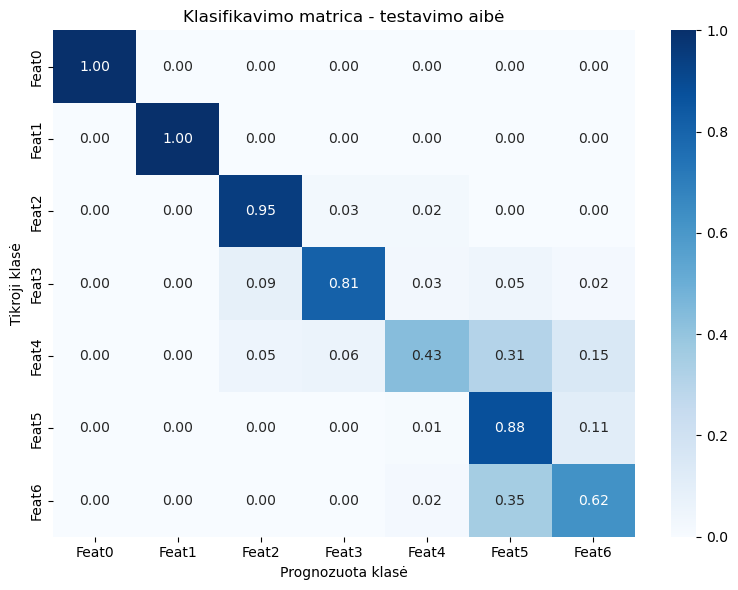

In [31]:
cm = confusion_matrix(y_test, y_pred_knn)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Prognozuota klasė')
ax.set_ylabel('Tikroji klasė')
ax.set_title('Klasifikavimo matrica - testavimo aibė')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Tikslumas per RPM

In [32]:
test_df = test_df.copy()
test_df['pred'] = le.inverse_transform(y_pred_knn)
test_df['correct'] = (test_df['pred'] == test_df['Feature'])

rpm_acc = test_df.groupby('Sukiai(rpm)')['correct'].mean().reset_index()
rpm_acc.columns = ['Sūkiai', 'Tikslumas']
print('Tikslumas kiekvienam sūkių skaičiui (2 bandymas):')
print(rpm_acc.to_string(index=False))

Tikslumas kiekvienam sūkių skaičiui (2 bandymas):
 Sūkiai  Tikslumas
   1000   0.767619
   2000   0.866667
   3000   0.840000
   4000   0.855238
   5000   0.735238


## 5. Tikslumas per apkrovą

In [33]:
load_acc = test_df.groupby('Apkrova(Nm)')['correct'].mean().reset_index()
load_acc.columns = ['Apkrova (Nm)', 'Tikslumas']
print('Tikslumas kiekvienai apkrovai (2 bandymas):')
print(load_acc.to_string(index=False))

Tikslumas kiekvienai apkrovai (2 bandymas):
 Apkrova (Nm)  Tikslumas
           25   0.786667
           50   0.845714
           75   0.899048
          100   0.766667
          125   0.763810


## 6. Šilumos žemėlapis (sūkiai X Gedimas)

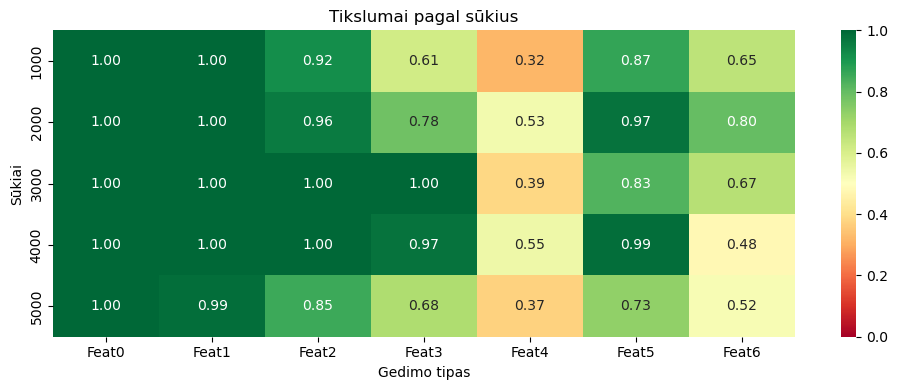

In [34]:
rpm_class = test_df.groupby(['Sukiai(rpm)', 'Feature'])['correct'].mean().unstack('Feature')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(rpm_class, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax)
ax.set_title('Tikslumai pagal sūkius')
ax.set_xlabel('Gedimo tipas')
ax.set_ylabel('Sūkiai')
plt.tight_layout()
plt.savefig('accuracy_rpm_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Šilumos žemėlapis (apkrova X Gedimas)

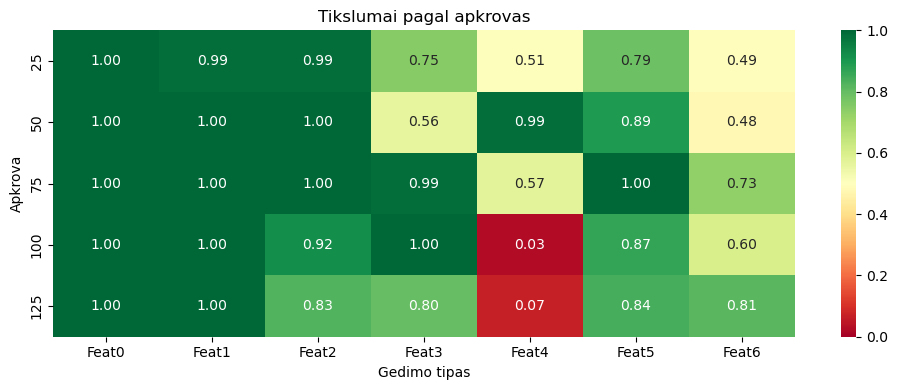

In [35]:
rpm_class = test_df.groupby(['Apkrova(Nm)', 'Feature'])['correct'].mean().unstack('Feature')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(rpm_class, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax)
ax.set_title('Tikslumai pagal apkrovas')
ax.set_xlabel('Gedimo tipas')
ax.set_ylabel('Apkrova')
plt.tight_layout()
plt.savefig('accuracy_nm_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()